In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import os
import glob
import yaml


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import os

if os.path.exists("/kaggle/input/dsai-unified-dataset"):
    DATA_PATH = "/kaggle/input/dsai-unified-dataset"
else:
    DATA_PATH = "/kaggle/input/datasets/ds22f1001123/dsai-unified-dataset"

print("Using dataset path:", DATA_PATH)

Using dataset path: /kaggle/input/datasets/ds22f1001123/dsai-unified-dataset


In [4]:
with open("data.yaml", "w") as f:
    f.write(f"""
path: {DATA_PATH}

train: images/train
val: images/val

names:
  0: person
  1: table
  2: potted plant
  3: chair
  4: sofa
  5: lamp
  6: door
  7: cabinet
  8: wardrobe
  9: refrigerator
  10: bed
""")

In [5]:
model = YOLO("yolo11s.pt")
DATA_YAML = "/kaggle/working/data.yaml"

In [6]:
# with open("YAML.yaml", "w") as f:
#     f.write("""
# path: /kaggle/input/datasets/ds22f1001123/dsai-unified-dataset

# train: images/train
# val: images/val

# names:
#   0: person
#   1: table
#   2: potted plant
#   3: chair
#   4: sofa
#   5: lamp
#   6: door
#   7: cabinet
#   8: wardrobe
#   9: refrigerator
#   10: bed
#     """)

In [7]:
results = model.train(
    data=DATA_YAML,
    epochs=100,
    imgsz=640,
    batch=32,          # 🔥 important
    device=0,

    degrees=8.0,
    translate=0.08,
    scale=0.25,
    fliplr=0.5,
    hsv_h=0.01,
    hsv_s=0.5,
    hsv_v=0.3,

    patience=20
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=8.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plo

In [8]:
val_model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

metrics = val_model.val(data=DATA_YAML)

print(f"mAP@50-95: {metrics.box.map:.4f}")
print(f"mAP@50:    {metrics.box.map50:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,417,057 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 195.9±73.9 MB/s, size: 151.5 KB)
val: Scanning /kaggle/input/datasets/ds22f1001123/dsai-unified-dataset/labels/val... 2340 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2340/2340 752.2it/s 3.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ds22f1001123/dsai-unified-dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 147/147 5.4it/s 27.0s
                   all       2340      10428      0.701      0.593      0.639      0.428
                person        989       3681      0.763      0.624      0.697       0.45
                 table        678        970      0.718      0.617      0.671      0.462
          potted plant        460       1204      0.702  

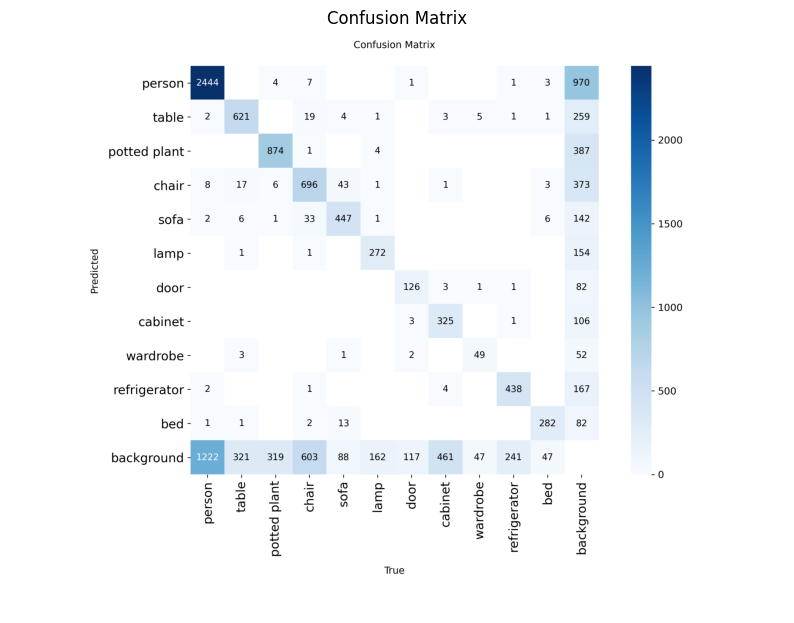

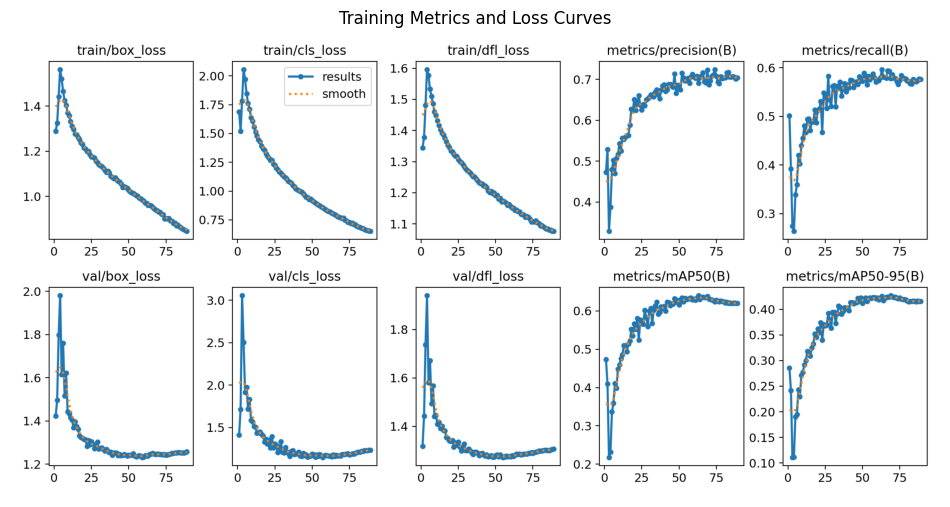

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_dir = '/kaggle/working/runs/detect/train/'

plt.figure(figsize=(10, 10))
img = mpimg.imread(os.path.join(results_dir, 'confusion_matrix.png'))
plt.imshow(img)
plt.axis('off')
plt.title('Confusion Matrix')
plt.show()

plt.figure(figsize=(12, 8))
img = mpimg.imread(os.path.join(results_dir, 'results.png'))
plt.imshow(img)
plt.axis('off')
plt.title('Training Metrics and Loss Curves')
plt.show()